In [27]:
!pip install gdown  # Install gdown if not already installed
import gdown
import zipfile

# File ID from Google Drive
file_id = "1_worUmGvse2YcXLzBdlgdqpU7luXUie5"
output_zip = "paddy-disease-classification.zip"

# Download the ZIP file
gdown.download(f"https://drive.google.com/uc?id={file_id}", output_zip, quiet=False)

# Extract the ZIP file
extract_path = "/content/paddy-disease-classification"
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset downloaded and extracted successfully!")


Downloading...
From (original): https://drive.google.com/uc?id=1_worUmGvse2YcXLzBdlgdqpU7luXUie5
From (redirected): https://drive.google.com/uc?id=1_worUmGvse2YcXLzBdlgdqpU7luXUie5&confirm=t&uuid=6cf85f11-5be7-4ed8-8ad8-9478feb21120
To: /content/paddy-disease-classification.zip
100%|██████████| 1.09G/1.09G [00:13<00:00, 80.3MB/s]


✅ Dataset downloaded and extracted successfully!


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from PIL import Image
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
# Configuration
DATA_DIR = "/content/paddy-disease-classification/paddy-disease-classification/"
TRAIN_DIR = os.path.join(DATA_DIR, "train_images")
TEST_DIR = os.path.join(DATA_DIR, "test_images")
CSV_PATH = os.path.join(DATA_DIR, "train.csv")
BATCH_SIZE = 16
IMAGE_SIZE = 256  # EfficientNetV2-M uses 384x384
EPOCHS = 30
NUM_CLASSES = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
scaler = torch.cuda.amp.GradScaler()

<ipython-input-23-a07aef3d7a4b>:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [4]:
# Class names from your dataset
CLASS_NAMES = {
    'normal': 'Healthy',
    'blast': 'Blast',
    'hispa': 'Hispa',
    'dead_heart': 'Dead Heart',
    'tungro': 'Tungro',
    'brown_spot': 'Brown Spot',
    'downy_mildew': 'Downy Mildew',
    'bacterial_leaf_blight': 'Bacterial Leaf Blight',
    'bacterial_leaf_streak': 'Bacterial Leaf Streak',
    'bacterial_panicle_blight': 'Bacterial Panicle Blight'
}

In [5]:
from sklearn.preprocessing import LabelEncoder
# Initialize label encoder
label_encoder = LabelEncoder()
label_encoder.fit(list(CLASS_NAMES.keys()))

LabelEncoder()

In [23]:
# Data Augmentation - simplified for memory efficiency
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# Dataset Class with memory optimizations
class PaddyDiseaseDataset(Dataset):
    def __init__(self, df, transform=None, has_labels=True):
        self.df = df
        self.transform = transform
        self.has_labels = has_labels

        if self.has_labels:
            self.labels = label_encoder.transform(df['label'])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['path']

        # Load image with explicit garbage collection
        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)

            if self.has_labels:
                label = self.labels[idx]
                return image, torch.tensor(label, dtype=torch.long)
            return image
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # Return a dummy image if there's an error
            dummy_img = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
            return dummy_img, torch.tensor(0) if self.has_labels else dummy_img

# Create dataframes from both folder structure and CSV
def create_dataframes():
    # Load the CSV file
    train_csv = pd.read_csv(CSV_PATH)

    # For training data
    train_data = []
    for class_name in os.listdir(TRAIN_DIR):
        class_dir = os.path.join(TRAIN_DIR, class_name)
        if os.path.isdir(class_dir):
            for img_name in os.listdir(class_dir):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_dir, img_name)
                    train_data.append({
                        'image_id': img_name,
                        'path': img_path,
                        'label': class_name
                    })

    train_df = pd.DataFrame(train_data)

    # For test data
    test_data = []
    for img_name in os.listdir(TEST_DIR):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(TEST_DIR, img_name)
            test_data.append({
                'image_id': img_name,
                'path': img_path
            })

    test_df = pd.DataFrame(test_data)
    return train_df, test_df

In [ ]:
# Prepare datasets
print("Loading dataset...")
train_df, test_df = create_dataframes()

# Calculate class weights
class_counts = train_df['label'].value_counts()
class_weights = 1. / class_counts
class_weights = class_weights / class_weights.sum()
class_weights = torch.tensor(class_weights[label_encoder.transform(class_counts.index)].values,
                       dtype=torch.float32).to(DEVICE)

# Split into train and validation
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df['label'],
    random_state=42
)


Loading dataset...


<ipython-input-32-14e4c0d96cc2>:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  class_weights = torch.tensor(class_weights[label_encoder.transform(class_counts.index)].values,


In [ ]:
# Create datasets with optimized DataLoader settings
train_dataset = PaddyDiseaseDataset(train_df, train_transform, has_labels=True)
val_dataset = PaddyDiseaseDataset(val_df, val_transform, has_labels=True)
test_dataset = PaddyDiseaseDataset(test_df, val_transform, has_labels=False)

# Optimized DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=2
)

# Memory-efficient model with Grad-CAM
class EfficientNetV2WithCAM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Use smaller variant for T4 GPU
        self.backbone = models.efficientnet_v2_s(weights='DEFAULT')

        # Feature extractor
        self.features = self.backbone.features
        self.avgpool = self.backbone.avgpool

        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.3, inplace=True),
            nn.Linear(self.backbone.classifier[1].in_features, num_classes)
        )

        # Grad-CAM hooks
        self.gradients = None
        self.activations = None

        # Register hooks on last conv layer
        target_layer = self.features[-1][-1]
        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output.detach()

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

    def get_activations_gradient(self):
        return self.gradients

    def get_activations(self):
        return self.activations

# Initialize model with memory optimizations
print("Initializing model...")
model = EfficientNetV2WithCAM(NUM_CLASSES).to(DEVICE)

# Freeze early layers to save memory
for param in model.features[:5].parameters():
    param.requires_grad = False

# Print model summary
summary(model, (3, IMAGE_SIZE, IMAGE_SIZE))

Initializing model...


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth
100%|██████████| 82.7M/82.7M [00:01<00:00, 77.3MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 24, 128, 128]             648
            Conv2d-2         [-1, 24, 128, 128]             648
       BatchNorm2d-3         [-1, 24, 128, 128]              48
       BatchNorm2d-4         [-1, 24, 128, 128]              48
              SiLU-5         [-1, 24, 128, 128]               0
              SiLU-6         [-1, 24, 128, 128]               0
            Conv2d-7         [-1, 24, 128, 128]           5,184
            Conv2d-8         [-1, 24, 128, 128]           5,184
       BatchNorm2d-9         [-1, 24, 128, 128]              48
      BatchNorm2d-10         [-1, 24, 128, 128]              48
             SiLU-11         [-1, 24, 128, 128]               0
             SiLU-12         [-1, 24, 128, 128]               0
  StochasticDepth-13         [-1, 24, 128, 128]               0
  StochasticDepth-14         [-1, 24, 1

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


In [ ]:
# Loss and optimizer with mixed precision
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001,
    weight_decay=0.01
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler()

<ipython-input-35-ae0d663bdb01>:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
# Training function with gradient accumulation
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    optimizer.zero_grad()

    pbar = tqdm(loader, desc='Training')
    for i, (images, labels) in enumerate(pbar):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Mixed precision forward
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels) / GRAD_ACCUM_STEPS

        # Backward pass
        scaler.scale(loss).backward()

        # Step only after accumulation
        if (i + 1) % GRAD_ACCUM_STEPS == 0 or (i + 1) == len(loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        running_loss += loss.item() * GRAD_ACCUM_STEPS
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        pbar.set_postfix({
            'loss': running_loss/((i+1)*BATCH_SIZE),
            'acc': 100*correct/total
        })

    return running_loss/len(loader), 100*correct/total


In [ ]:
# Validation function
def validate(model, loader, criterion, device):
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validation'):
            images = images.to(device)
            labels = labels.to(device)

            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return val_loss/len(loader), 100*correct/total

# Clear cache before training
torch.cuda.empty_cache()

In [ ]:
# Training loop
print("Starting training...")
best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # Train and validate
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    # Update history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': val_loss,
            'accuracy': val_acc,
            'label_encoder': label_encoder.classes_
        }, '/content/best_model.pth')
        print(f"New best model saved with val_acc: {val_acc:.2f}%")

    # Clear cache periodically
    if (epoch + 1) % 5 == 0:
        torch.cuda.empty_cache()

Starting training...

Epoch 1/30


Training:   0%|          | 0/520 [00:00<?, ?it/s]<ipython-input-36-c5b715e813cc>:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validation:   0%|          | 0/131 [00:00<?, ?it/s]<ipython-input-37-1154bef7536e>:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validation: 100%|██████████| 131/131 [00:14<00:00,  8.82it/s]


New best model saved with val_acc: 88.47%

Epoch 2/30


Validation: 100%|██████████| 131/131 [00:15<00:00,  8.72it/s]



Epoch 3/30


...

Validation: 100%|██████████| 131/131 [00:16<00:00,  8.14it/s]



Epoch 29/30


Validation: 100%|██████████| 131/131 [00:15<00:00,  8.55it/s]



Epoch 30/30


Validation: 100%|██████████| 131/131 [00:14<00:00,  8.76it/s]


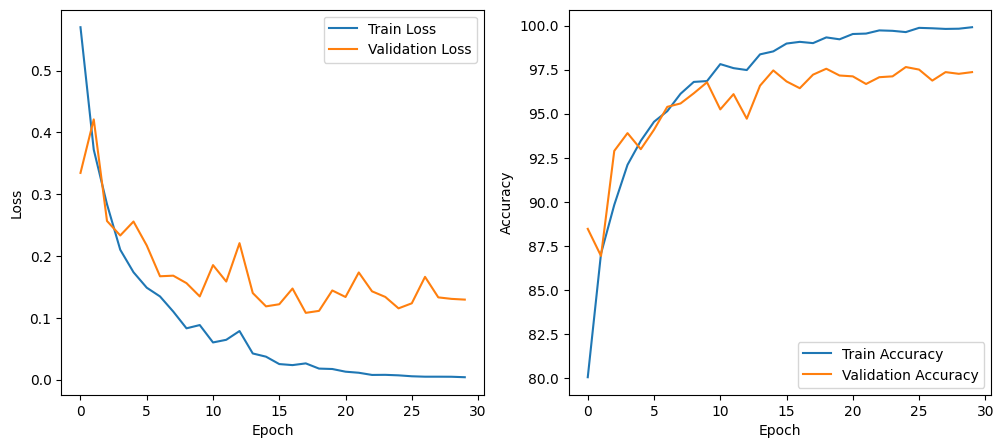

In [ ]:
# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [17]:
# 1. First, define the EXACT model architecture that matches your saved weights
class EfficientNetV2WithCAM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.efficientnet_v2_s(weights='DEFAULT')

        # Feature extractor
        self.features = self.backbone.features
        self.avgpool = self.backbone.avgpool

        # Classifier - must match your training architecture
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.3, inplace=True),
            nn.Linear(self.backbone.classifier[1].in_features, num_classes)
        )

        # Grad-CAM hooks
        self.gradients = None
        self.activations = None

        # Register hooks
        target_layer = self.features[-1][-1]
        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

    def get_activations_gradient(self):
        return self.gradients

    def get_activations(self):
        return self.activations

# 2. Now load the model properly
model = EfficientNetV2WithCAM(num_classes=10).to(DEVICE)

# Load with proper weight handling
try:
    # First try safe loading
    with torch.serialization.safe_globals([torch._utils._rebuild_tensor_v2]):
        checkpoint = torch.load('/content/best_model.pth', weights_only=True)
    model.load_state_dict(checkpoint['model_state_dict'])
    print("✅ Model loaded safely with weights_only=True")
except:
    # Fallback to unsafe loading ONLY if you trust the source
    checkpoint = torch.load('/content/best_model.pth', weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print("⚠️ Model loaded with weights_only=False - only use if you trust the source")

model.eval()


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth
100%|██████████| 82.7M/82.7M [00:00<00:00, 169MB/s]


⚠️ Model loaded with weights_only=False - only use if you trust the source


EfficientNetV2WithCAM(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): B

In [41]:
def generate_gradcam(model, img_path, transform, label_encoder, class_names, device='cuda'):
    """
    Robust Grad-CAM visualization with comprehensive error handling

    Args:
        model: Your trained PyTorch model
        img_path: Path to input image
        transform: Image transformations
        label_encoder: Label encoder for class names
        class_names: List of class names
        device: Computation device ('cuda' or 'cpu')

    Returns:
        tuple: (result_image, predicted_class)
    """
    try:
        # 1. Load and verify image
        img = Image.open(img_path).convert('RGB')
        img_tensor = transform(img).unsqueeze(0).to(device)

        # 2. Forward pass with gradients
        model.zero_grad()
        model.eval()
        img_tensor.requires_grad_()

        # 3. Run prediction
        with torch.cuda.amp.autocast(enabled=(device=='cuda')):
            pred = model(img_tensor)
            pred_class = torch.argmax(pred).item()
            class_name = label_encoder.inverse_transform([pred_class])[0]
            pred[0, pred_class].backward()

        # 4. Get gradients and activations
        gradients = model.get_activations_gradient()
        activations = model.get_activations()

        # 5. Process heatmap
        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3], keepdim=True)
        weighted_activations = activations * pooled_gradients
        heatmap = torch.mean(weighted_activations, dim=1).squeeze()

        # 6. Normalize heatmap
        heatmap = heatmap.detach().cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        if np.max(heatmap) > 0:
            heatmap /= np.max(heatmap)

        # 7. Prepare for visualization
        img_np = np.array(img)
        heatmap = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

        # 8. Superimpose and return
        superimposed_img = cv2.addWeighted(heatmap, 0.4, img_np, 0.6, 0)
        return Image.fromarray(superimposed_img), class_names[class_name]

    except Exception as e:
        print(f"Grad-CAM error for {img_path}: {str(e)}")
        # Return blank image with error message
        blank_img = Image.new('RGB', (224, 224), color='gray')
        return blank_img, "Prediction Error"

In [45]:
# Example usage
def visualize_gradcam(image_path):
    # Load your model (do this once at startup)
    # model = ... (your model loading code)

    result_img, pred_class = generate_gradcam(
        model=model,
        img_path=image_path,
        transform=val_transform,
        label_encoder=label_encoder,
        class_names=CLASS_NAMES,
        device=DEVICE
    )

    plt.figure(figsize=(10, 6))
    plt.imshow(result_img)
    plt.title(f"Predicted: {pred_class}", fontsize=14, pad=10)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return pred_class

<ipython-input-41-1d84ea6a4cfd>:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device=='cuda')):
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


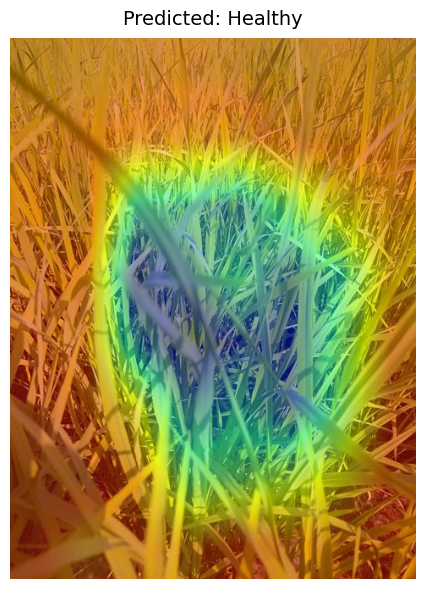

'Healthy'

In [46]:
# Test it
image_path = "/content/paddy-disease-classification/paddy-disease-classification/train_images/normal/100007.jpg"
visualize_gradcam(image_path)

In [47]:
!pip list

Package                            Version
---------------------------------- -------------------
absl-py                            1.4.0
accelerate                         1.5.2
aiohappyeyeballs                   2.6.1
aiohttp                            3.11.14
aiosignal                          1.3.2
alabaster                          1.0.0
albucore                           0.0.23
albumentations                     2.0.5
ale-py                             0.10.2
altair                             5.5.0
annotated-types                    0.7.0
anyio                              4.9.0
argon2-cffi                        23.1.0
argon2-cffi-bindings               21.2.0
array_record                       0.7.1
arviz                              0.21.0
astropy                            7.0.1
astropy-iers-data                  0.2025.3.24.0.35.32
astunparse                         1.6.3
atpublic                           5.1
attrs                              25.3.0
audioread            

In [6]:
# In your training notebook, check:
print(label_encoder.classes_)

['bacterial_leaf_blight' 'bacterial_leaf_streak'
 'bacterial_panicle_blight' 'blast' 'brown_spot' 'dead_heart'
 'downy_mildew' 'hispa' 'normal' 'tungro']
